# XP Exercises: Flower Classification using CNN

This is a guided notebook for the exercises on the platform. Cells marked **PREFILLED** are for execution only. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

Learning points appear only for key concepts that unlock intuition or transfer to other ML topics.


## What you will learn
- Building a CNN for multi class image classification
- Data loading and preprocessing with `image_dataset_from_directory`
- Image visualization techniques
- Model architecture design, compilation, and training
- Evaluating model performance with accuracy and loss plots


## What you will create
A CNN model that classifies 14 flower species.
All parts form one continuous exercise. Work through them sequentially.


## Dataset
**As stated in the exercises**  
Flower classification with 14 classes. Images are organized in class folders. A training and validation split may be provided. Images are resized to 256x256 in this notebook.

**PREFILLED info**  
This notebook expects the provided zip file to be available. The code below extracts it and locates the dataset root automatically.


In [7]:
import requests

# URL of the zip file provided by the user
zip_url = "https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/Week%206/W6D3/Flower%20Classification.zip"
zip_filename = "Flower Classification.zip"

print(f"Downloading {zip_filename}...")
response = requests.get(zip_url, stream=True)
response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)

with open(zip_filename, 'wb') as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)

print(f"Successfully downloaded {zip_filename}")

Successfully downloaded Flower Classification.zip


In [8]:
# PREFILLED: just execute
import os, sys, zipfile, shutil, glob, math, json, random
from pathlib import Path

DATA_ZIP = Path("./Flower Classification.zip")
EXTRACT_DIR = Path("./data/flower_data")

# Clean extract dir if re-running
if EXTRACT_DIR.exists():
    pass  # avoid deleting in case you added files; delete manually if needed
else:
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

# Extract if a zip is present and not already extracted
if DATA_ZIP.exists():
    # Heuristically decide to extract once
    marker = EXTRACT_DIR / ".extracted"
    if not marker.exists():
        with zipfile.ZipFile(DATA_ZIP, 'r') as zf:
            zf.extractall(EXTRACT_DIR)
        marker.write_text("ok")
        print("Extracted:", DATA_ZIP.name, "->", EXTRACT_DIR)
    else:
        print("Already extracted. Skipping.")
else:
    print("Zip file not found at", DATA_ZIP)

# Find candidate dataset roots: a dir with >= 10 subdirs assumed as classes, or contains train/val
def list_dirs(p):
    return [d for d in Path(p).iterdir() if d.is_dir()]

candidates = []
for root, dirs, files in os.walk(EXTRACT_DIR):
    if len([d for d in Path(root).iterdir() if Path(d).is_dir()]) >= 10:
        candidates.append(Path(root))
    if "train" in [d.name.lower() for d in list_dirs(root)] and "val" in [d.name.lower() for d in list_dirs(root)]:
        candidates.append(Path(root))

candidates = sorted(set(candidates))
print("Candidate dataset roots:", [str(c) for c in candidates][:5])

Extracted: Flower Classification.zip -> data/flower_data
Candidate dataset roots: ['data/flower_data/Data', 'data/flower_data/Data/train', 'data/flower_data/Data/val']


## Part 1. Data exploration and visualization

**As stated in the exercises**  
Load the dataset using `image_dataset_from_directory`. Print number of images per class. Modify `visualize_images` to show a 3x3 grid for each class with the class name as the grid title. Analyze challenges you anticipate when classifying the flowers such as similar colors or shapes and intra class variation.


**Guidance**  
If a `train` or `val` folder exists, use them. Otherwise create a split from a single root with `validation_split` and `subset`. Images are resized to 256x256 RGB.


> **IMPORTANT:** we fix a low resultion for images in IMG_SIZE=(32,32) for faster training, however you can change it if you want to test out other resolutions

In [9]:
# PREFILLED: just execute
import tensorflow as tf
from tensorflow.keras import layers

IMG_SIZE = (32, 32)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

def detect_layout(root: Path):
    root = Path(root)
    sub = [d.name.lower() for d in root.iterdir() if d.is_dir()]
    if "train" in sub and "val" in sub:
        return "provided_split", root
    return "single_root", root

# Choose a root
if 'candidates' in globals() and len(candidates) > 0:
    DS_ROOT = candidates[0]
else:
    DS_ROOT = EXTRACT_DIR  # fallback

layout, base = detect_layout(DS_ROOT)
print("Layout:", layout, "Base:", base)

Layout: provided_split Base: data/flower_data/Data


In [10]:
# PREFILLED: just execute
if layout == "provided_split":
    train_dir = next((p for p in base.iterdir() if p.name.lower()=="train"))
    val_dir   = next((p for p in base.iterdir() if p.name.lower()=="val"))
    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, label_mode="int"
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, label_mode="int"
    )
else:
    train_ds = tf.keras.utils.image_dataset_from_directory(
        base, validation_split=0.2, subset="training", seed=SEED,
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int"
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        base, validation_split=0.2, subset="validation", seed=SEED,
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int"
    )

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", num_classes, class_names)

# Cache and prefetch
def prepare(ds):
    return ds.cache().prefetch(AUTOTUNE)

train_ds = prepare(train_ds)
val_ds = prepare(val_ds)

Found 13642 files belonging to 14 classes.
Found 98 files belonging to 14 classes.
Classes: 14 ['astilbe', 'bellflower', 'black_eyed_susan', 'calendula', 'california_poppy', 'carnation', 'common_daisy', 'coreopsis', 'dandelion', 'iris', 'rose', 'sunflower', 'tulip', 'water_lily']


In [11]:
# PREFILLED: just execute — count images per class by scanning directory
from collections import Counter
import os

def count_images_per_class(root):
    counts = {}
    for cls in class_names:
        # find folder named like cls at any depth under base
        matches = list(Path(base).rglob(cls))
        if matches:
            folder = matches[0]
            img_count = sum(1 for p in folder.rglob("*") if p.suffix.lower() in {".jpg",".jpeg",".png",".bmp",".gif"})
            counts[cls] = img_count
        else:
            counts[cls] = None
    return counts

base = "/content/data/flower_data/Data/train"
counts = count_images_per_class(base)
counts

{'astilbe': 726,
 'bellflower': 872,
 'black_eyed_susan': 986,
 'calendula': 1011,
 'california_poppy': 1021,
 'carnation': 924,
 'common_daisy': 978,
 'coreopsis': 1035,
 'dandelion': 1038,
 'iris': 1041,
 'rose': 986,
 'sunflower': 1013,
 'tulip': 1034,
 'water_lily': 977}

In [12]:
# To-Do: implement visualize_images to display a 3x3 grid for each class
# Hints:
# def visualize_images(dataset, class_names, per_class=9):
#     # iterate batches, collect images by label until you have 9 per class
#     # for each class, plot a 3x3 grid and set the figure suptitle to the class name
#     pass

In [24]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_images(dataset, class_names, per_class=9):
    # Dictionnaire pour stocker les images collectées par nom de classe
    images_collected = {class_name: [] for class_name in class_names}
    # Compteurs pour suivre le nombre d'images collectées par classe
    counts = {class_name: 0 for class_name in class_names}

    # Parcourir les lots du dataset pour collecter les images
    # Utiliser .take(1000) pour éviter de parcourir tout le dataset si trop grand
    for images, labels in dataset.unbatch().take(1000):
        # Obtenir le nom de la classe pour l'étiquette actuelle
        label_name = class_names[labels.numpy()]
        # Si nous n'avons pas encore atteint le nombre souhaité d'images pour cette classe
        if counts[label_name] < per_class:
            images_collected[label_name].append(images.numpy())
            counts[label_name] += 1
        # Si nous avons collecté suffisamment d'images pour toutes les classes, arrêter
        if all(c >= per_class for c in counts.values()):
            break

    # Afficher les images pour chaque classe
    for class_name in class_names:
        if len(images_collected[class_name]) > 0:
            # Créer une grille 3x3 pour les images de la classe actuelle
            fig, axes = plt.subplots(3, 3, figsize=(8, 8))
            # Définir le titre de la figure avec le nom de la classe
            fig.suptitle(f"Classe: {class_name}", fontsize=16)
            axes = axes.flatten() # Aplatir le tableau d'axes pour une itération facile
            for i in range(min(per_class, len(images_collected[class_name]))):
                ax = axes[i]
                # S'assurer que l'image est au bon format (par exemple, uint8 pour l'affichage)
                img = (images_collected[class_name][i] * 255).astype(np.uint8)
                ax.imshow(img)
                ax.axis("off") # Désactiver les axes pour une meilleure visualisation
            # Désactiver les sous-graphiques inutilisés si moins de `per_class` images sont affichées
            for j in range(len(images_collected[class_name]), per_class):
                axes[j].axis("off")
            plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajuster la mise en page
            plt.show() # Afficher la figure
        else:
            # Message si aucune image n'a été collectée pour une classe
            print(f"Aucune image collectée pour la classe: {class_name}")

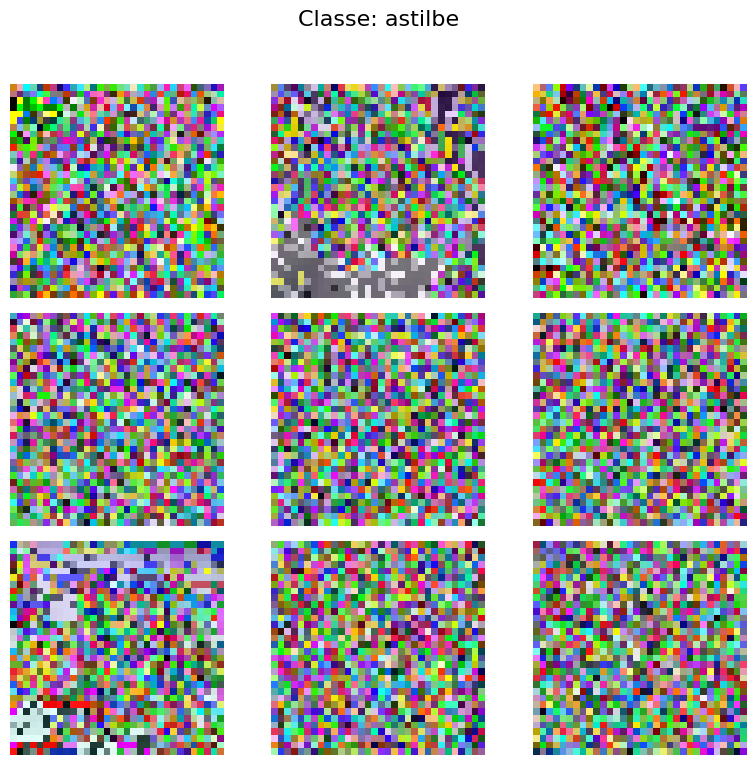

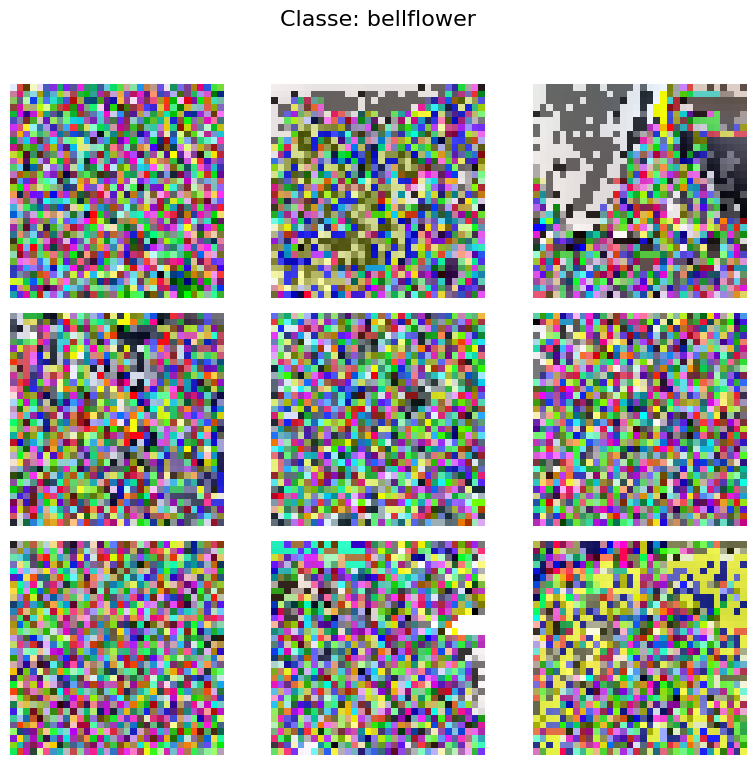

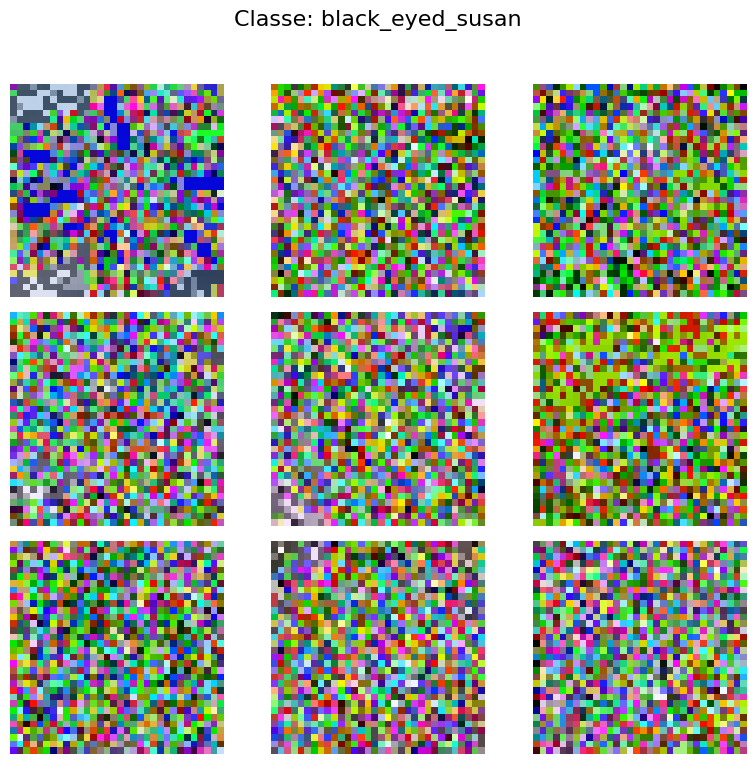

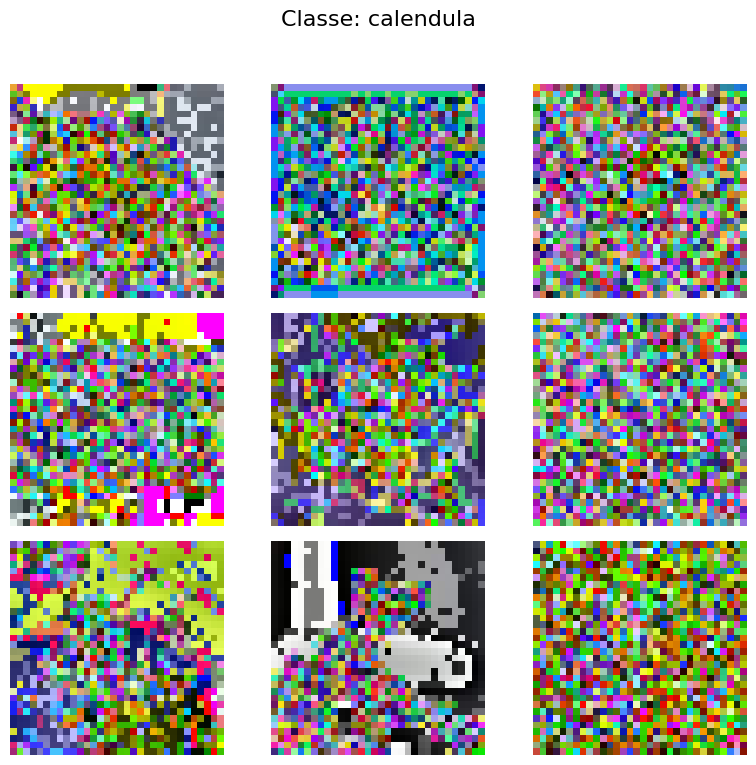

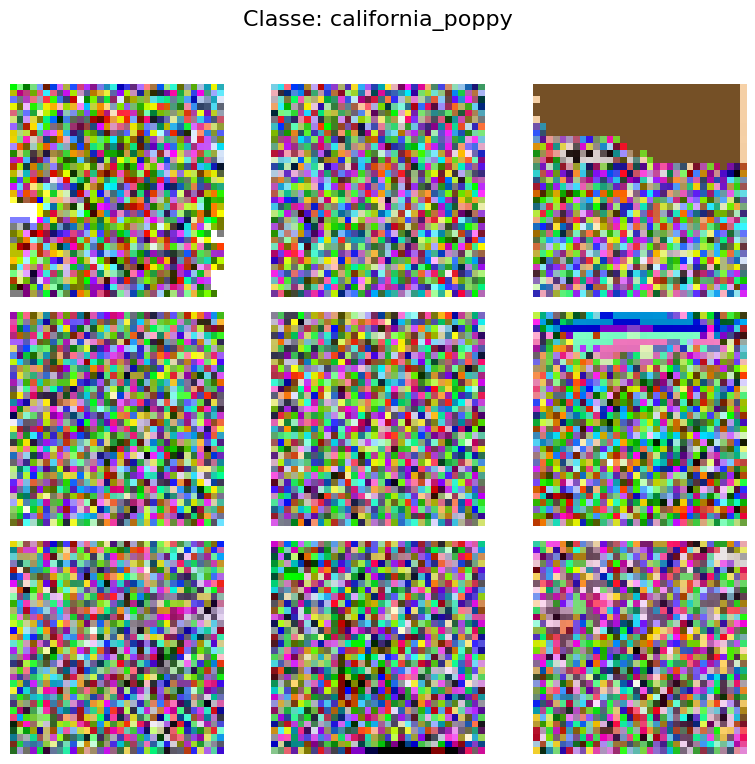

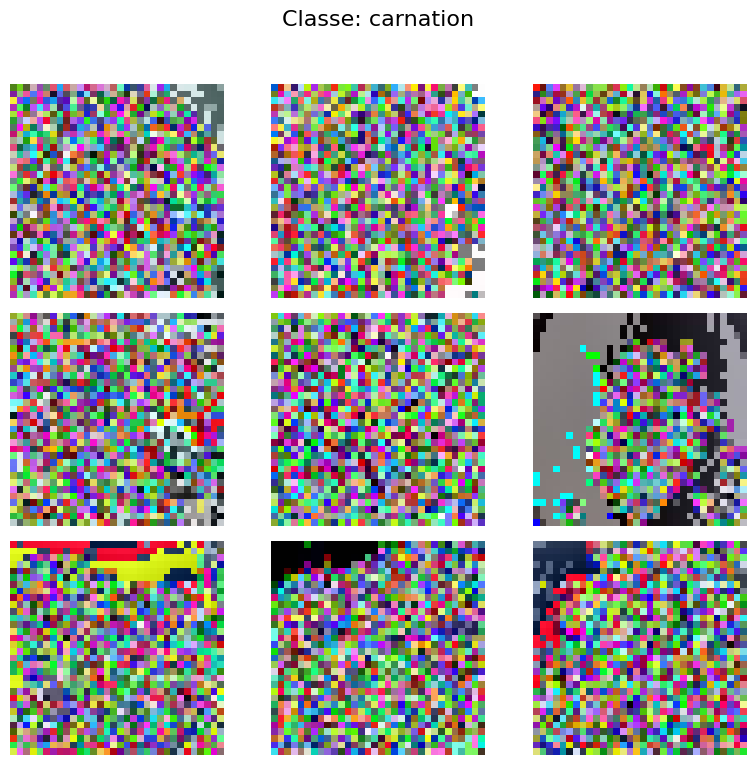

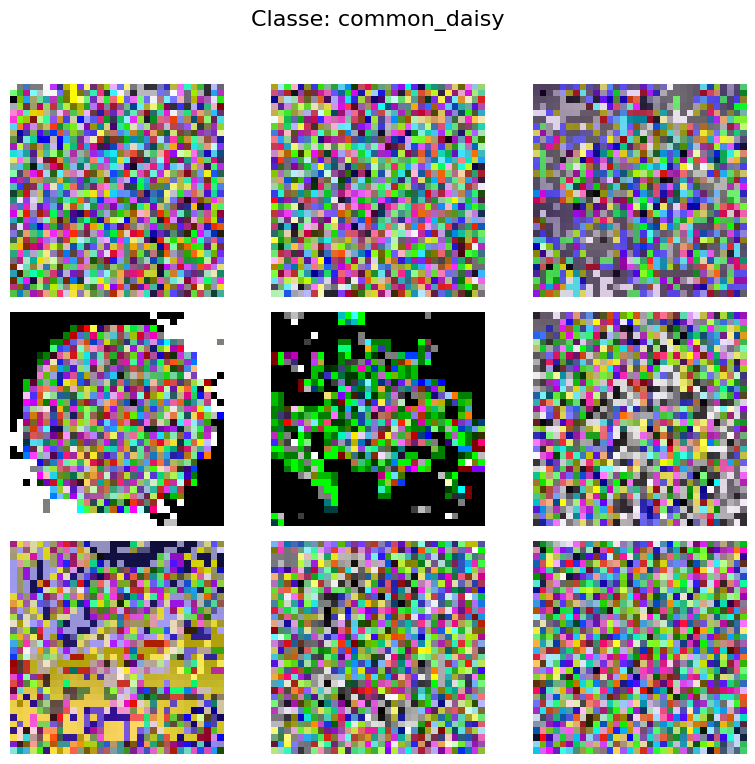

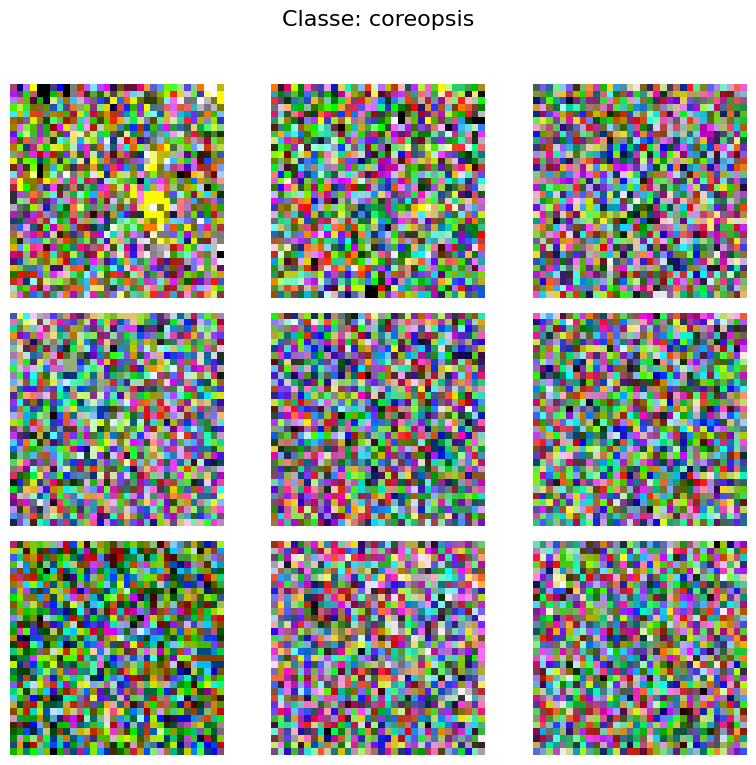

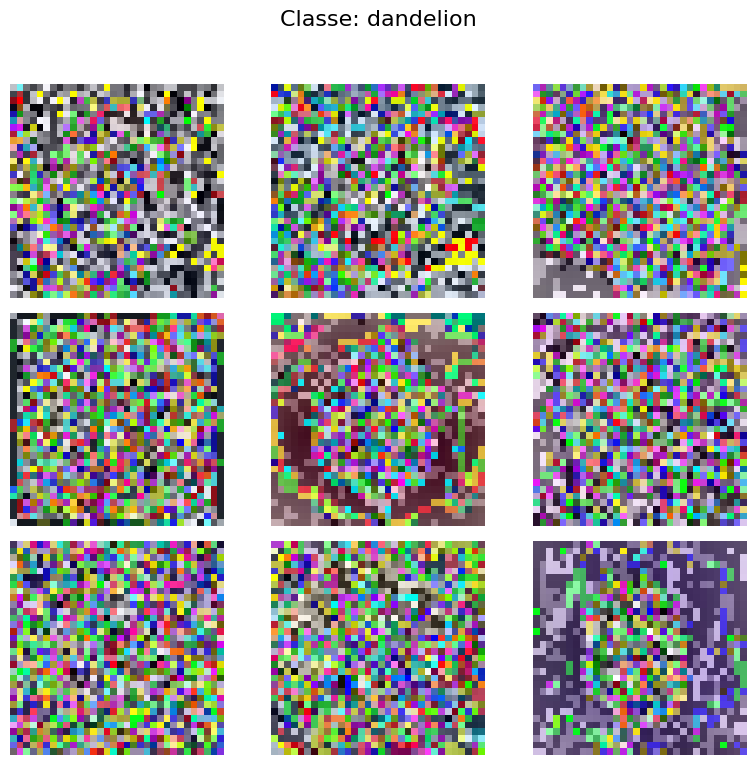

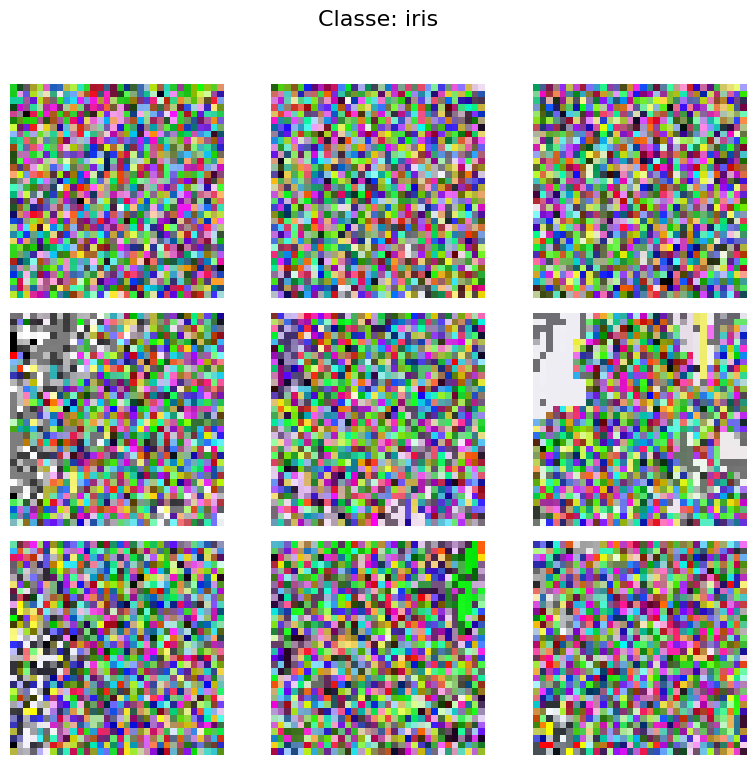

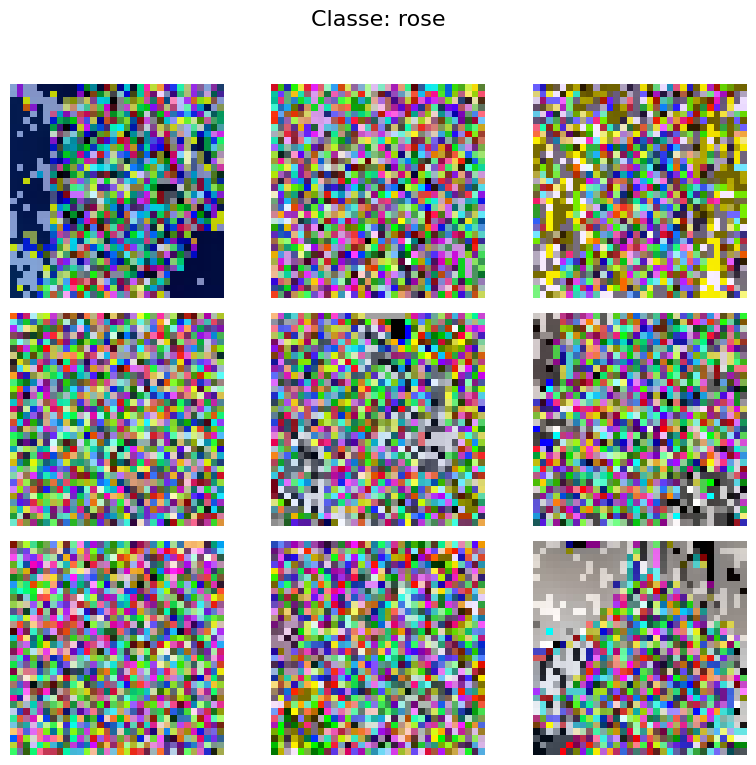

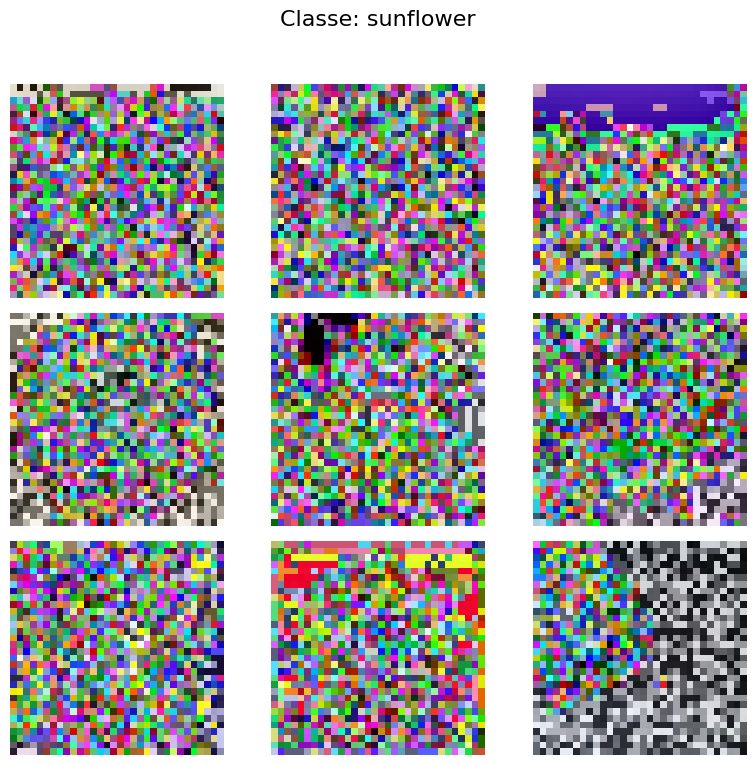

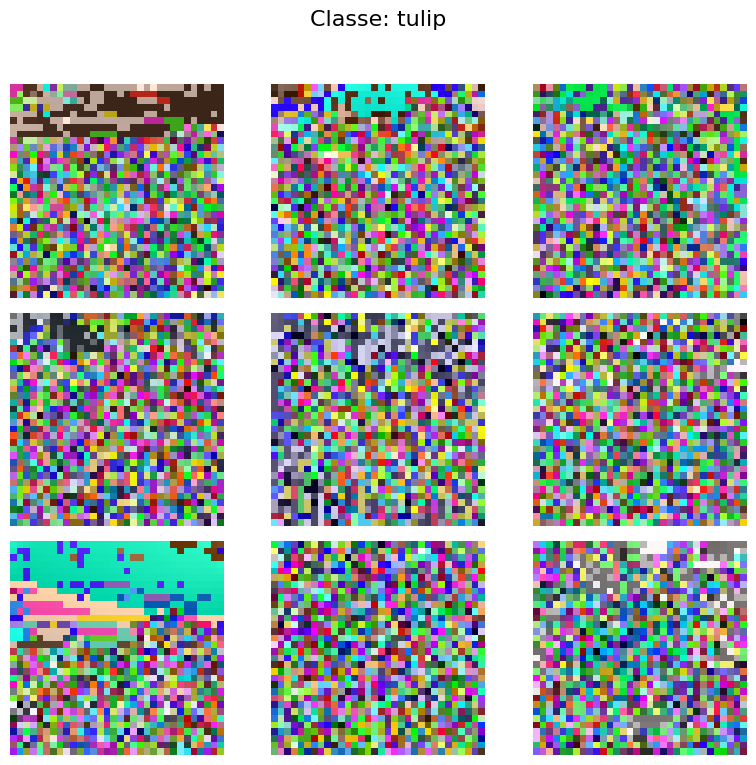

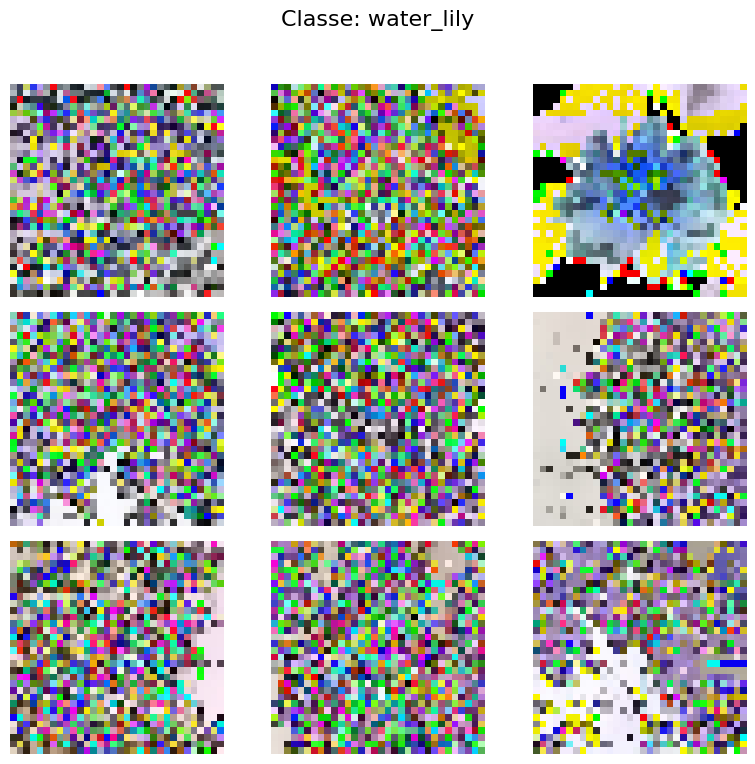

In [25]:
# Appeler la fonction visualize_images sur un sous-ensemble du dataset d'entraînement
# Nous prendrons une petite portion de train_ds à visualiser
visualize_images(train_ds, class_names)

**To-Do:** After you implement `visualize_images`, run it on a small subset to verify class distributions visually.


**To-Do (written):** Analyze expected challenges for classification in 4 to 6 sentences. Mention similar color palettes across species, intra class variation due to background and lighting, and class imbalance if present.


**Learning point**  
Vision models learn features from texture, color, and shape. Dataset bias and imbalance can dominate results without careful preprocessing and evaluation.


## Part 2. Model architecture design

**As stated in the exercises**  
Start from the provided model. Experiment with the number of convolutional layers, filters, kernel sizes, max pooling layers. Try different dense layers and dropout. Consider Batch Normalization. Justify your architectural choices.


In [15]:
# PREFILLED: just execute — baseline model scaffold
from tensorflow.keras import models

def build_baseline(num_classes):
    model = models.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),
        layers.Rescaling(1./255),  # safety if datasets were not normalized
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

baseline = build_baseline(num_classes)
baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,326 (1.36 MB)

 Trainable params: 357,326 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# To-Do: create an improved architecture variant
# Suggestions:
# - Add BatchNormalization after Conv2D or Dense
# - Try kernel sizes 5x5 in early layers
# - Increase filters progressively 32->64->128->256
# - Adjust Dropout to 0.4
# def build_variant(num_classes):
#     pass
# model_variant = build_variant(num_classes)
# model_variant.summary()

**To-Do (written):** Justify your chosen layers and parameters in 4 to 6 sentences. Refer to receptive field growth, normalization stabilizing training, and dropout for regularization.


## Part 3. Hyperparameter tuning

**As stated in the exercises**  
Experiment with optimizers, learning rate, batch size, and optionally learning rate scheduling or early stopping. Track experiments and results. Report the best combination.


In [17]:
# PREFILLED: just execute — utilities for training and plotting
import time

def fit_model(model, train_ds, val_ds, epochs=5, callbacks=None):
    t0 = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=callbacks, verbose=2)
    dt = time.time() - t0
    return history, dt

def plot_curves(history, title="Training"):
    plt.figure(figsize=(6,4))
    plt.plot(history.history.get("accuracy", []), label="acc")
    plt.plot(history.history.get("val_accuracy", []), label="val_acc")
    plt.title(title); plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend(); plt.tight_layout(); plt.show()
    plt.figure(figsize=(6,4))
    plt.plot(history.history.get("loss", []), label="loss")
    plt.plot(history.history.get("val_loss", []), label="val_loss")
    plt.title(title); plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.tight_layout(); plt.show()

In [18]:
# To-Do: run a few experiments
# Example search space
# opts = [
#   ("adam", 1e-3, 32),
#   ("adam", 5e-4, 32),
#   ("rmsprop", 1e-3, 32),
#   ("sgd", 1e-2, 64),
# ]
# results = []
# for opt_name, lr, batch in opts:
#     # rebuild model each time
#     model = build_baseline(num_classes)  # or your variant
#     if opt_name == "adam":
#         optimizer = tf.keras.optimizers.Adam(lr)
#     elif opt_name == "rmsprop":
#         optimizer = tf.keras.optimizers.RMSprop(lr)
#     else:
#         optimizer = tf.keras.optimizers.SGD(lr, momentum=0.9, nesterov=True)
#     model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
#     cb = [tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)]
#     hist, dur = fit_model(model, train_ds, val_ds, epochs=8, callbacks=cb)
#     best_val = max(hist.history["val_accuracy"])
#     results.append({"opt": opt_name, "lr": lr, "batch": batch, "best_val_acc": float(best_val), "time_s": round(dur,1)})
# results

**To-Do (written):** Report the best hyperparameters you found and briefly explain why they might work well for this dataset.


## Part 4. Data augmentation

**As stated in the exercises**  
Implement data augmentation using `ImageDataGenerator`. Explore rotation, flipping, zooming, shifting, and shearing. Determine which augmentations help most and explain why.


**Guidance**  
Since we used `image_dataset_from_directory` above, you can either:  
Option A. Rebuild input using `ImageDataGenerator.flow_from_directory` on the training directory.  
Option B. Keep the tf.data pipeline and apply Keras preprocessing layers such as `RandomFlip`, `RandomRotation`.  
The exercises asks for `ImageDataGenerator`, so Option A shows that path.


In [19]:
# To-Do: build an ImageDataGenerator pipeline (Option A)
# from tensorflow.keras.preprocessing.image import ImageDataGenerator
# train_dir = next((p for p in Path(base).iterdir() if p.name.lower()=='train'), None)
# if train_dir is None:
#     train_dir = base  # if single root
# datagen = ImageDataGenerator(
#     rescale=1./255,
#     rotation_range=20,
#     width_shift_range=0.1,
#     height_shift_range=0.1,
#     shear_range=0.1,
#     zoom_range=0.1,
#     horizontal_flip=True,
#     fill_mode='nearest',
#     validation_split=0.2
# )
# flow_train = datagen.flow_from_directory(train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
#                                         class_mode='sparse', subset='training', seed=SEED)
# flow_val = datagen.flow_from_directory(train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
#                                       class_mode='sparse', subset='validation', seed=SEED)
# model_aug = build_baseline(num_classes)  # or your variant
# hist_aug = model_aug.fit(flow_train, validation_data=flow_val, epochs=8, verbose=2)
# plot_curves(hist_aug, title='Augmented training')

**Learning point**  
Augmentation encodes invariances like rotation and translation. It increases effective sample diversity which often reduces overfitting.


## Part 5. Performance evaluation and analysis

**As stated in the exercises**  
Plot training and validation curves. Compute precision, recall, F1, and a confusion matrix. Visualize predictions on a test set and analyze misclassifications.


In [20]:
# PREFILLED: just execute — helpers for evaluation on a dataset
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

def collect_preds(model, ds):
    y_true = []
    y_prob = []
    for xb, yb in ds:
        pr = model.predict(xb, verbose=0)
        y_prob.append(pr)
        y_true.append(yb.numpy())
    y_true = np.concatenate(y_true)
    y_prob = np.concatenate(y_prob)
    if y_prob.ndim == 2 and y_prob.shape[1] > 1:
        y_pred = y_prob.argmax(axis=1)
    else:
        y_pred = (y_prob.ravel() >= 0.5).astype(int)
    return y_true, y_pred, y_prob

def plot_confusion(cm, labels):
    plt.figure(figsize=(6,6))
    plt.imshow(cm)
    plt.title("Confusion matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    ticks = np.arange(len(labels))
    plt.xticks(ticks, labels, rotation=90)
    plt.yticks(ticks, labels)
    plt.tight_layout()
    plt.show()

In [21]:
# To-Do: evaluate your best model on val_ds
# best_model = model_aug or model_variant or baseline
# y_true, y_pred, y_prob = collect_preds(best_model, val_ds)
# print(classification_report(y_true, y_pred, target_names=class_names, digits=3))
# cm = confusion_matrix(y_true, y_pred)
# plot_confusion(cm, class_names)

In [22]:
# To-Do: visualize a few predictions and inspect errors
# import random
# take = 12
# imgs, labels = next(iter(val_ds.unbatch().batch(take)))
# probs = best_model.predict(imgs, verbose=0)
# preds = probs.argmax(axis=1)
# for i in range(take):
#     plt.figure(figsize=(2.5,2.5))
#     plt.imshow(imgs[i].numpy().astype('uint8'))
#     t = f"true: {class_names[int(labels[i])]}\npred: {class_names[int(preds[i])]}"
#     plt.title(t)
#     plt.axis("off")
#     plt.tight_layout()
#     plt.show()

**To-Do (written):** Identify classes that your model finds difficult. Explain possible causes such as similar morphology or color, or small sample counts.


## Part 6. Model saving and deployment (optional)

**As stated in the exercises**  
Save your trained model in `.h5` or SavedModel format. Optionally consider web or cloud deployment.


In [23]:
# To-Do: save your best model
# best_model.save("./data/flower_cnn_savedmodel")  # SavedModel directory
# best_model.save("./data/flower_cnn.h5")  # H5 file
# print("Saved to ./data/")